In [1]:
import pandas as pd

df = pd.read_csv('StudentsPerformance.csv')

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [3]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
df['average_score'] = (
    df['math score']
    + df['reading score']
    + df['writing score']
) / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [8]:
print("Math Average:", round(df['math score'].mean(), 2))

print("Reading Average:", round(df['reading score'].mean(), 2))

print("Writing Average:", round(df['writing score'].mean(), 2))

Math Average: 66.09
Reading Average: 69.17
Writing Average: 68.05


In [9]:
gender_analysis = df.groupby('gender')[
    ['math score',
     'reading score',
     'writing score']
].mean()

gender_analysis

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [10]:
prep_analysis = df.groupby(
    'test preparation course'
)['average_score'].mean()

prep_analysis

,average_score
test preparation course,
completed,72.669460
none,65.038941


In [11]:
lunch_analysis = df.groupby(
    'lunch'
)['average_score'].mean()

lunch_analysis

,average_score
lunch,
free/reduced,62.199061
standard,70.837209


In [12]:
parent_analysis = df.groupby(
    'parental level of education'
)['average_score'].mean()

parent_analysis.sort_values(
    ascending=False
)

,average_score
parental level of education,
master's degree,73.598870
bachelor's degree,71.923729
associate's degree,69.569069
some college,68.476401
some high school,65.108007
high school,63.096939


In [13]:
top_students = df.sort_values(
    by='average_score',
    ascending=False
)

top_students.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
916,male,group E,bachelor's degree,standard,completed,100,100,100,100.000000
962,female,group E,associate's degree,standard,none,100,100,100,100.000000
458,female,group E,bachelor's degree,standard,none,100,100,100,100.000000
114,female,group E,bachelor's degree,standard,completed,99,100,100,99.666667
712,female,group D,some college,standard,none,98,100,99,99.000000
179,female,group D,some high school,standard,completed,97,100,100,99.000000
165,female,group C,bachelor's degree,standard,completed,96,100,100,98.666667
625,male,group D,some college,standard,completed,100,97,99,98.666667
685,female,group E,master's degree,standard,completed,94,99,100,97.666667
903,female,group D,bachelor's degree,free/reduced,completed,93,100,100,97.666667


In [15]:
df[['math score',
    'reading score',
    'writing score']].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


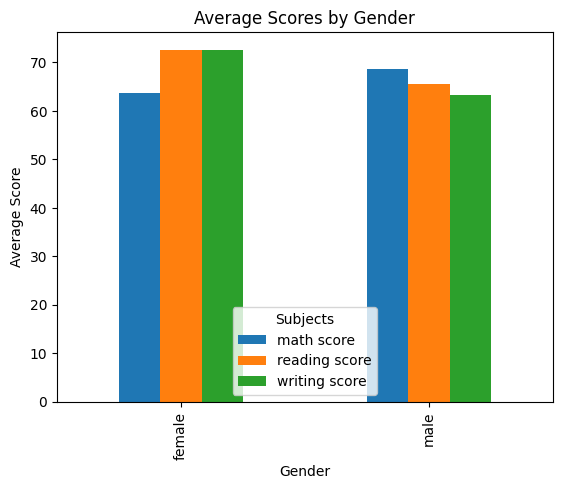

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

gender_analysis.plot(kind='bar')

plt.title('Average Scores by Gender')

plt.xlabel('Gender')

plt.ylabel('Average Score')

plt.legend(title='Subjects')
plt.savefig('gender_analysis.png')

plt.show()

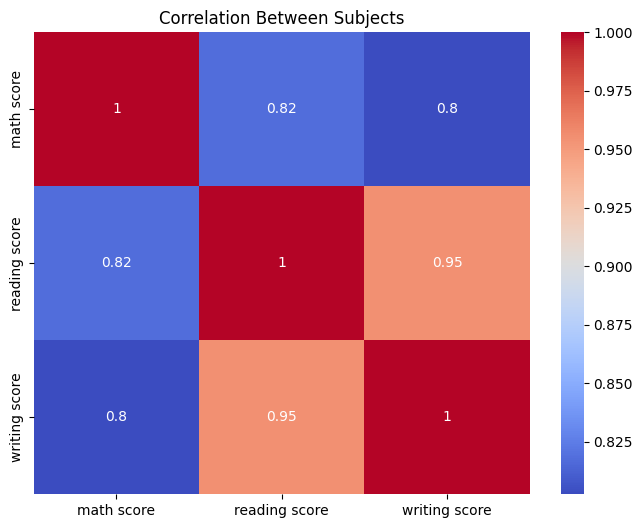

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['math score',
        'reading score',
        'writing score']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Between Subjects')
plt.savefig('correlation_heatmap.png')
plt.show()

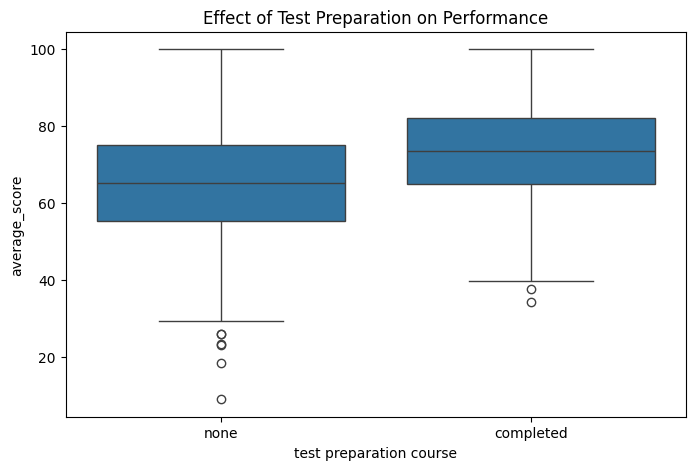

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='test preparation course',
    y='average_score',
    data=df
)

plt.title('Effect of Test Preparation on Performance')
plt.savefig('test_preparation.png')
plt.show()

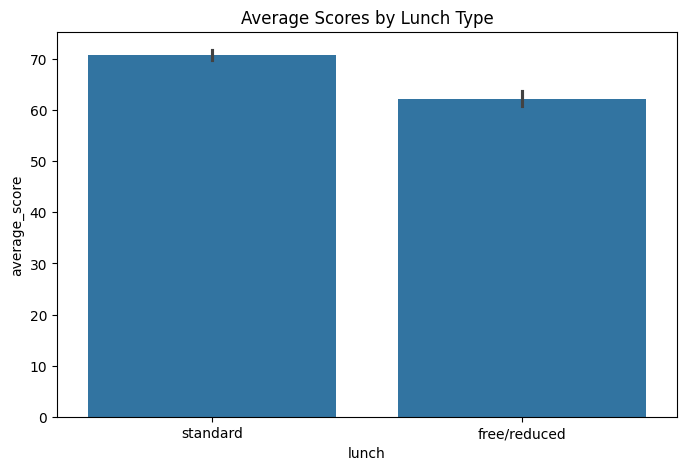

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='lunch',
    y='average_score',
    data=df
)

plt.title('Average Scores by Lunch Type')
plt.savefig('lunch_analysis.png')
plt.show()

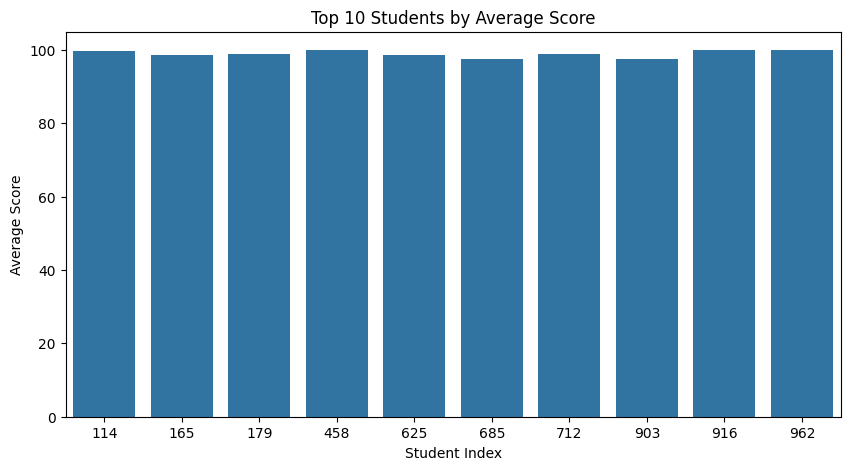

In [26]:
top10 = df.sort_values(
    by='average_score',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top10.index,
    y='average_score',
    data=top10
)

plt.title('Top 10 Students by Average Score')

plt.xlabel('Student Index')

plt.ylabel('Average Score')
plt.savefig('top_students.png')
plt.show()

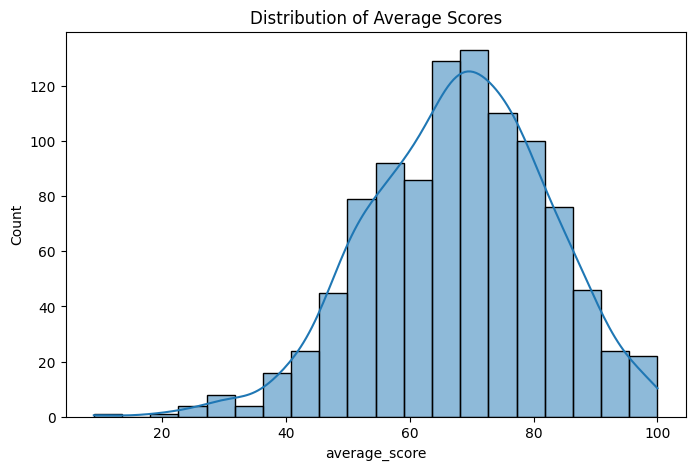

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['average_score'],
    bins=20,
    kde=True
)

plt.title('Distribution of Average Scores')
plt.savefig('score_distribution.png')
plt.show()

In [28]:
from google.colab import files

files.download('gender_analysis.png')
files.download('correlation_heatmap.png')
files.download('test_preparation.png')
files.download('lunch_analysis.png')
files.download('top_students.png')
files.download('score_distribution.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>